***EXP-3***
# *23A91A0459*
***S.Nikhil Prince***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
# -------------------------------------------------------
# 1) LOAD IRIS CSV FILE

# -------------------------------------------------------
df = pd.read_csv("/content/Iris.csv")
print("File Loaded Successfully!")
print(df.head())
print("Shape:", df.shape)

# If last column contains species labels
feature_columns = df.columns[:-1]
label_column = df.columns[-1]

X = df[feature_columns].values
y = df[label_column].values

print("\nFeatures:", feature_columns.tolist())
print("Target Column:", label_column)
print("Unique Classes:", np.unique(y))

File Loaded Successfully!
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa
Shape: (150, 5)

Features: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
Target Column: Species
Unique Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [ ]:
# -------------------------------------------------------
# 2) STANDARDIZE THE FEATURES
# -------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)
print(X_scaled[:5])

(150, 4)
[[-0.90068117  1.03205722 -1.3412724  -1.31297673]
 [-1.14301691 -0.1249576  -1.3412724  -1.31297673]
 [-1.38535265  0.33784833 -1.39813811 -1.31297673]
 [-1.50652052  0.10644536 -1.2844067  -1.31297673]
 [-1.02184904  1.26346019 -1.3412724  -1.31297673]]


In [ ]:
# -------------------------------------------------------
# 3) APPLY PCA (reduce to 2 components)
# -------------------------------------------------------
pca2 = PCA(n_components=3)
X_pca2 = pca2.fit_transform(X_scaled)

print("\nExplained Variance Ratio (2 Components):")
print(pca2.explained_variance_ratio_)


Explained Variance Ratio (2 Components):
[0.72770452 0.23030523 0.03683832]


In [ ]:
print("Total variance explained:", pca2.explained_variance_ratio_.sum())

Total variance explained: 0.9948480731910938


In [ ]:
print(X_pca2[:10])  # first 10 rows

[[-2.26454173  0.5057039   0.12194335]
 [-2.0864255  -0.65540473  0.22725083]
 [-2.36795045 -0.31847731 -0.05147962]
 [-2.30419716 -0.57536771 -0.09886044]
 [-2.38877749  0.6747674  -0.02142785]
 [-2.07053681  1.51854856 -0.03068426]
 [-2.44571134  0.07456268 -0.34219764]
 [-2.23384186  0.24761393  0.08257446]
 [-2.34195768 -1.09514636 -0.1535624 ]
 [-2.18867576 -0.44862905  0.24655952]]


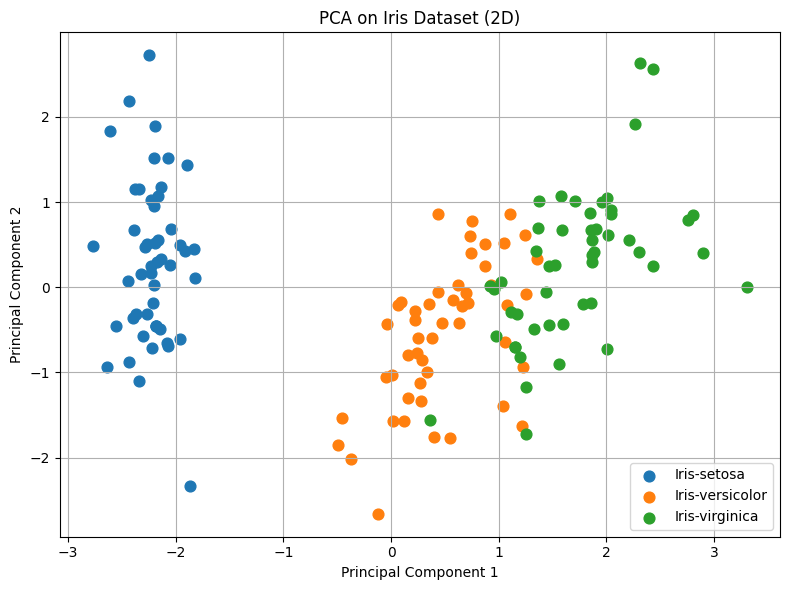

In [ ]:
# -------------------------------------------------------
# 4) 2D PCA SCATTER PLOT
# -------------------------------------------------------
plt.figure(figsize=(8,6))
for species in np.unique(y):
    plt.scatter(
        X_pca2[y == species, 0],
        X_pca2[y == species, 1],
        label=species,
        s=60
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA on Iris Dataset (2D)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Assistant
For a 3D PCA scatter plot, you need to use a 3D projection. Here's the corrected code:


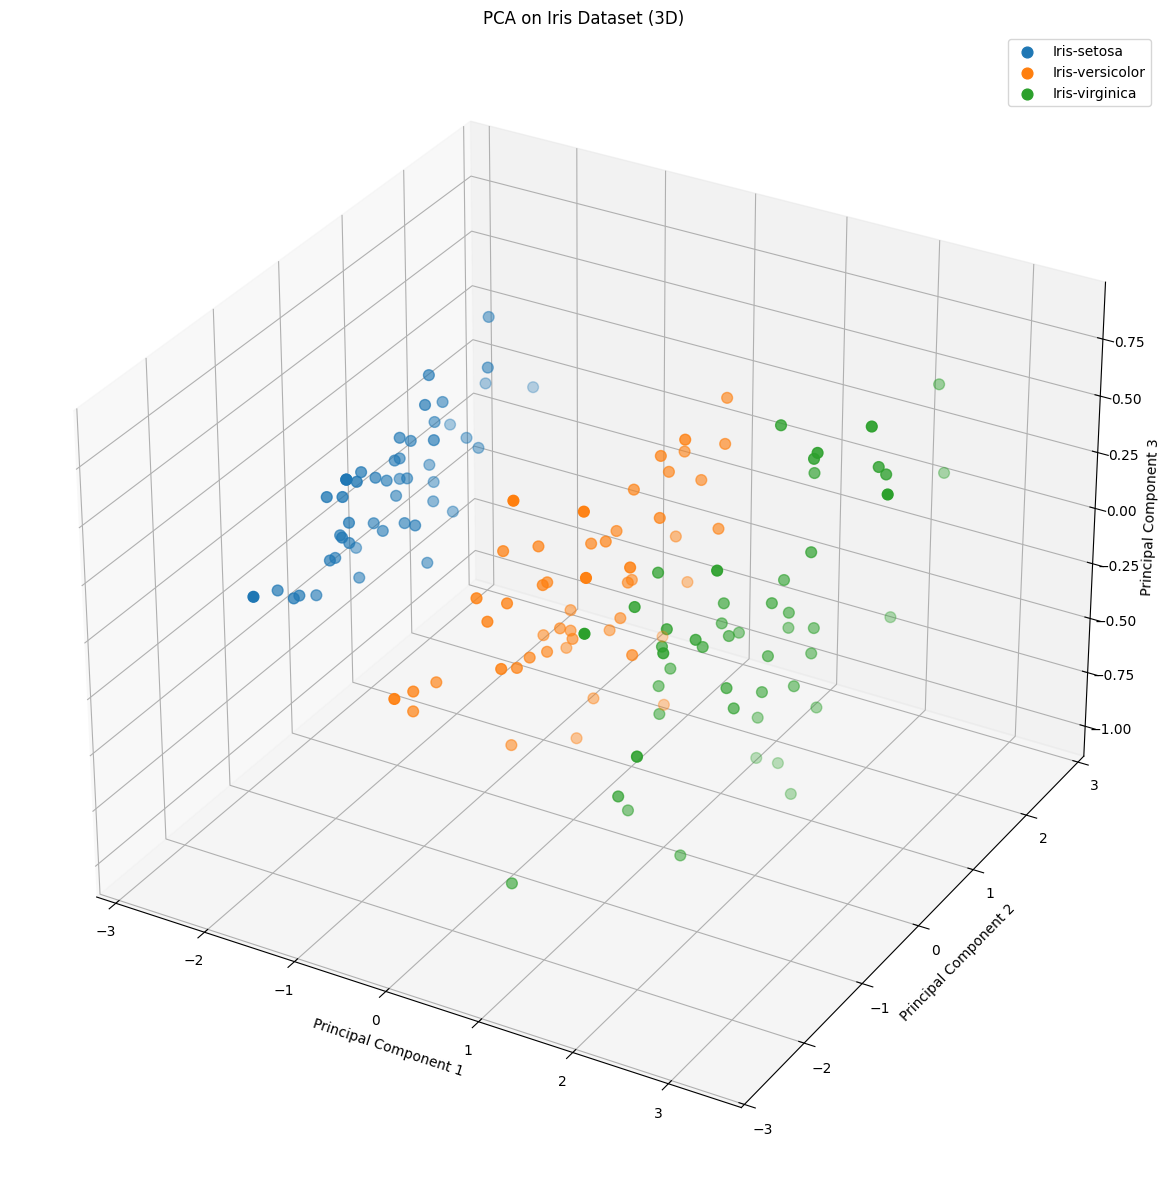

In [ ]:
# -------------------------------------------------------
# 3D PCA SCATTER PLOT
# -------------------------------------------------------
from mpl_toolkits.mplot3d import Axes3D  # Import for 3D plotting

# Create a 3D figure
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')  # Create 3D axes

for species in np.unique(y):
    ax.scatter(
        X_pca2[y == species, 0],  # x-coordinate (PC1)
        X_pca2[y == species, 1],  # y-coordinate (PC2)
        X_pca2[y == species, 2],  # z-coordinate (PC3)
        label=species,
        s=60
    )

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("PCA on Iris Dataset (3D)")
plt.legend()
plt.tight_layout()
plt.show()